<!-- CV-PATCHED -->

<a href="https://colab.research.google.com/github/flipiwolker-alt/cv-video-analytics/blob/main/notebooks/PZ_1_OpenCV_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ПЗ 1 — Обработка изображений (OpenCV)

Загружаем изображение, применяем базовые преобразования OpenCV, читаем числовой текст через EasyOCR.

In [ ]:
!pip install -q opencv-python-headless easyocr pandas matplotlib 'numpy<2'


In [ ]:
# Загрузка изображения: в Colab — через диалог, локально/при отмене — sample
import os, sys, urllib.request
file_path = None
if 'google.colab' in sys.modules:
    try:
        from google.colab import files
        uploaded = files.upload()
        if uploaded:
            file_path = list(uploaded.keys())[0]
    except Exception as e:
        print(f'[upload] пропуск: {e}')
if not file_path:
    file_path = '/tmp/sample.jpg'
    if not os.path.exists(file_path):
        urllib.request.urlretrieve(
            'https://ultralytics.com/images/bus.jpg', file_path
        )
    print(f'используем sample: {file_path}')


In [ ]:
import cv2
import numpy as np
import easyocr
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display

import torch
reader = easyocr.Reader(['ru', 'en'], gpu=torch.cuda.is_available())

img = cv2.imread(file_path)
if img is None:
    raise SystemExit(f'не удалось прочитать {file_path}')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

_, mask = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

R, G, B = cv2.split(img_rgb)

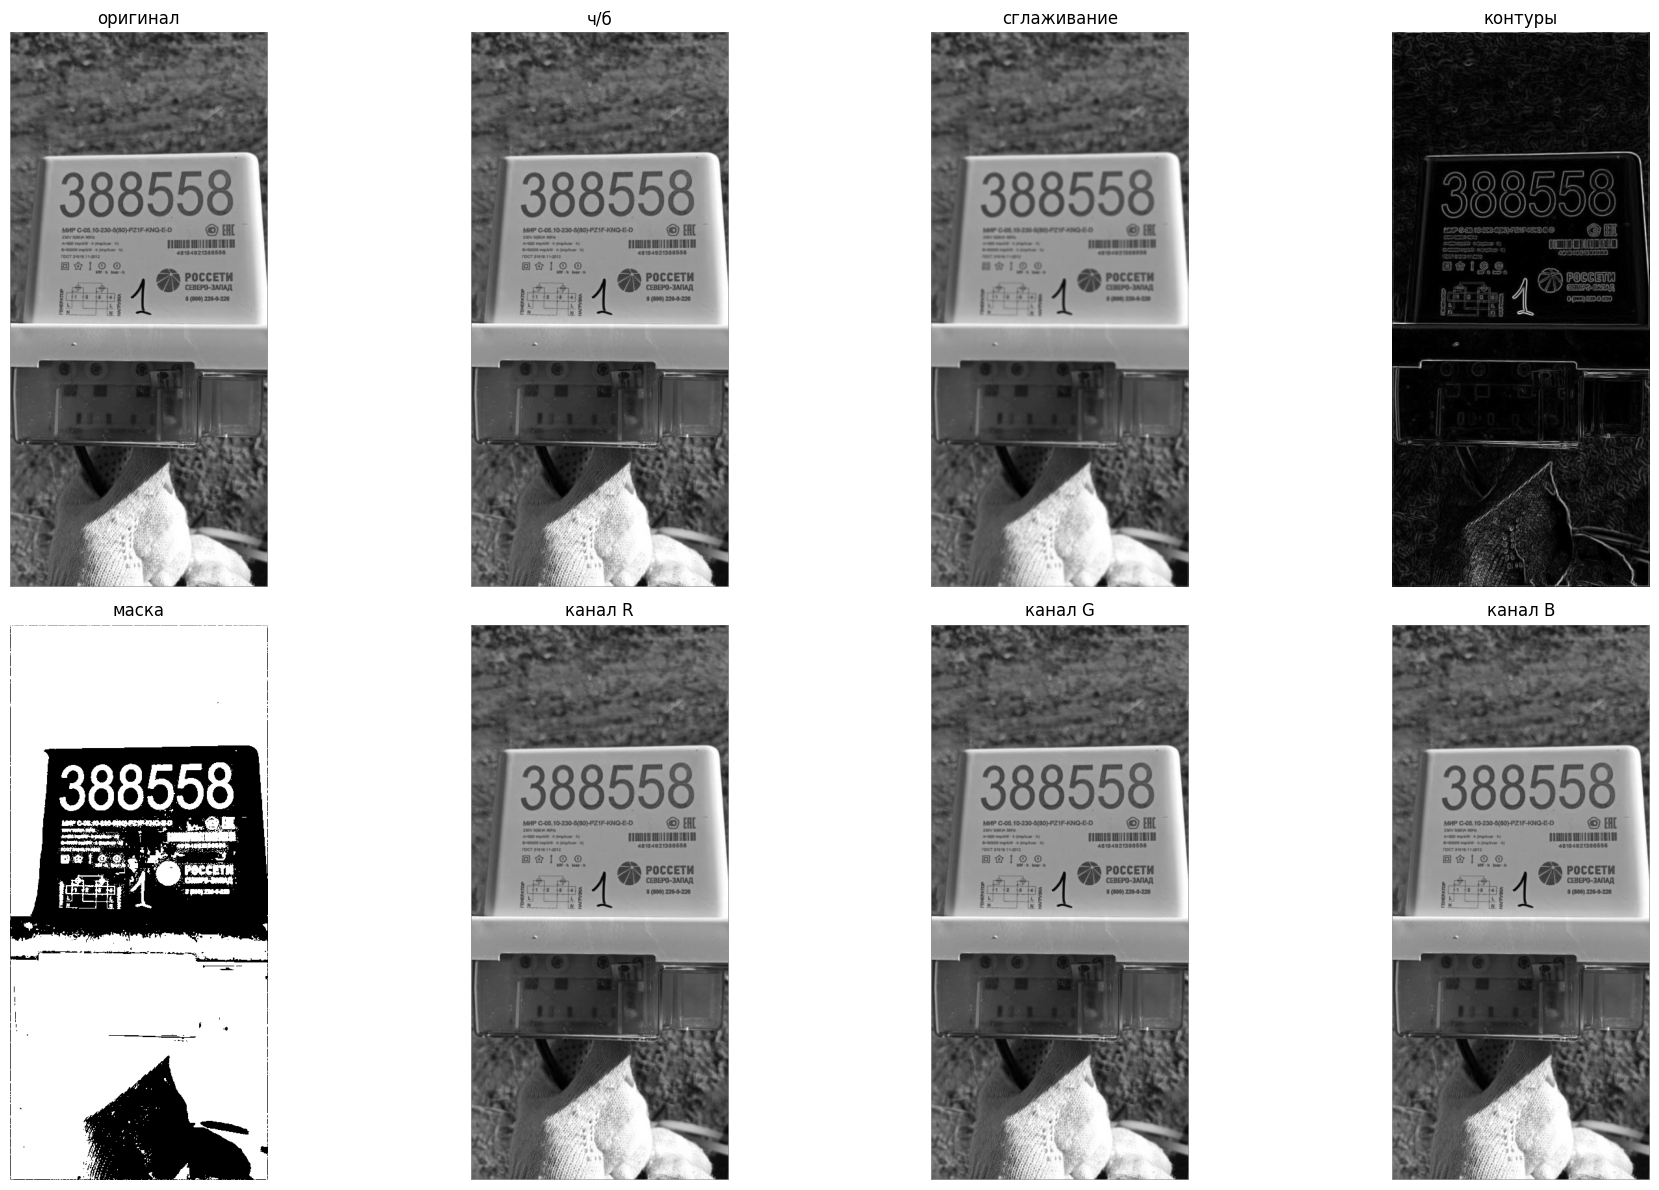

In [4]:
plt.figure(figsize=(20, 12))

panels = [
    (img_rgb,        'оригинал'),
    (gray,           'ч/б'),
    (blurred,        'сглаживание'),
    (sobel_combined, 'контуры'),
    (mask,           'маска'),
    (R,              'канал R'),
    (G,              'канал G'),
    (B,              'канал B'),
]

for i, (image, title) in enumerate(panels):
    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap='gray' if len(image.shape) == 2 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
results = reader.readtext(gray)
rows = []

for bbox, text, prob in results:
    digits = ''.join(filter(str.isdigit, text))
    if len(digits) >= 5:
        rows.append({
            'изображение': file_path.split('/')[-1],
            'результат':   digits,
            'уверенность': round(prob, 3),
        })
        break

if rows:
    display(pd.DataFrame(rows))
else:
    print('числовой текст не найден')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,изображение,результат,уверенность
0,photo_2026-05-07_05-38-18.jpg,388558,0.986
